# Exploratory Data Analysis - RACE Dataset

## 1. Setup + Imports

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import os
import re
import warnings
warnings.filterwarnings('ignore')

# Plot styling
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

BASE_DIR = r"/content/drive/MyDrive/Colab Notebooks/AI PROJECT/"
RAW_DATA_DIR = os.path.join(BASE_DIR, "data/raw/")
#RAW_DATA_DIR = '../data/raw/'  # for local on laptop
PLOTS_DIR = os.path.join(BASE_DIR, "notebooks/plots/")

# Create directories if they don't exist
os.makedirs(PLOTS_DIR, exist_ok=True)

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 2. Load the Dataset

In [45]:
# Load dataset
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [46]:
# Load all three splits
try:
    train_df = pd.read_csv(os.path.join(RAW_DATA_DIR, 'train.csv'), encoding='utf-8')
    dev_df   = pd.read_csv(os.path.join(RAW_DATA_DIR, 'dev.csv'), encoding='utf-8')
    test_df  = pd.read_csv(os.path.join(RAW_DATA_DIR, 'test.csv'), encoding='utf-8')
except UnicodeDecodeError:
    train_df = pd.read_csv(os.path.join(RAW_DATA_DIR, 'train.csv'), encoding='latin1')
    dev_df   = pd.read_csv(os.path.join(RAW_DATA_DIR, 'dev.csv'), encoding='latin1')
    test_df  = pd.read_csv(os.path.join(RAW_DATA_DIR, 'test.csv'), encoding='latin1')

print(f'Train rows : {len(train_df):,}')
print(f'Dev rows   : {len(dev_df):,}')
print(f'Test rows  : {len(test_df):,}')
print(f'\nColumns    : {list(train_df.columns)}')

Train rows : 87,866
Dev rows   : 87,866
Test rows  : 87,866

Columns    : ['Unnamed: 0', 'id', 'article', 'question', 'A', 'B', 'C', 'D', 'answer']


In [47]:
# Quick peek at data
train_df.head(3)

,Unnamed: 0,id,article,question,A,B,C,D,answer
0,0,middle7348.txt,In the summer between my first year and second...,Before the writer came to the high school summ...,instructor,camper,student,reporter,C
1,1,middle7348.txt,In the summer between my first year and second...,How many times did the writer invite the boy t...,Once,Twice,Three times,Many times,B
2,2,middle4305.txt,A bumpkin went to a big city for the first t...,The bumpkin thought _ .,his wife was as beautiful as the young girl,his wife was more beautiful than the short fat...,the short fat woman changed to a young girl in...,He should also buy a room of that kind for his...,C


## 3. Statistics + Missing Values

In [48]:
# Dataset shape summary
summary = pd.DataFrame({
    'Split'  : ['Train', 'Dev', 'Test'],
    'Rows'   : [len(train_df), len(dev_df), len(test_df)],
    'Columns': [train_df.shape[1], dev_df.shape[1], test_df.shape[1]]
})
print('=== Dataset Split Summary ===')
print(summary.to_string(index=False))

=== Dataset Split Summary ===
Split  Rows  Columns
Train 87866        9
  Dev 87866        9
 Test 87866        9


In [49]:
# Missing values check
print('=== Missing Values in Training Set ===')
missing = train_df.isnull().sum()
missing_pct = (missing / len(train_df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df)

if missing.sum() == 0:
    print('\nNo missing values found - dataset is clean!')
else:
    print(f'\nTotal missing cells: {missing.sum()}')

=== Missing Values in Training Set ===
            Missing Count  Missing %
Unnamed: 0              0       0.00
id                      0       0.00
article                 0       0.00
question                0       0.00
A                       4       0.00
B                       0       0.00
C                       1       0.00
D                       9       0.01
answer                  0       0.00

Total missing cells: 14


In [50]:
# Data types
print('=== Column Data Types ===')
print(train_df.dtypes)

=== Column Data Types ===
Unnamed: 0     int64
id            object
article       object
question      object
A             object
B             object
C             object
D             object
answer        object
dtype: object


## 4. Answer Label Distribution
We check whether A/B/C/D answers are balanced across the dataset. Imbalance would affect classifier training.

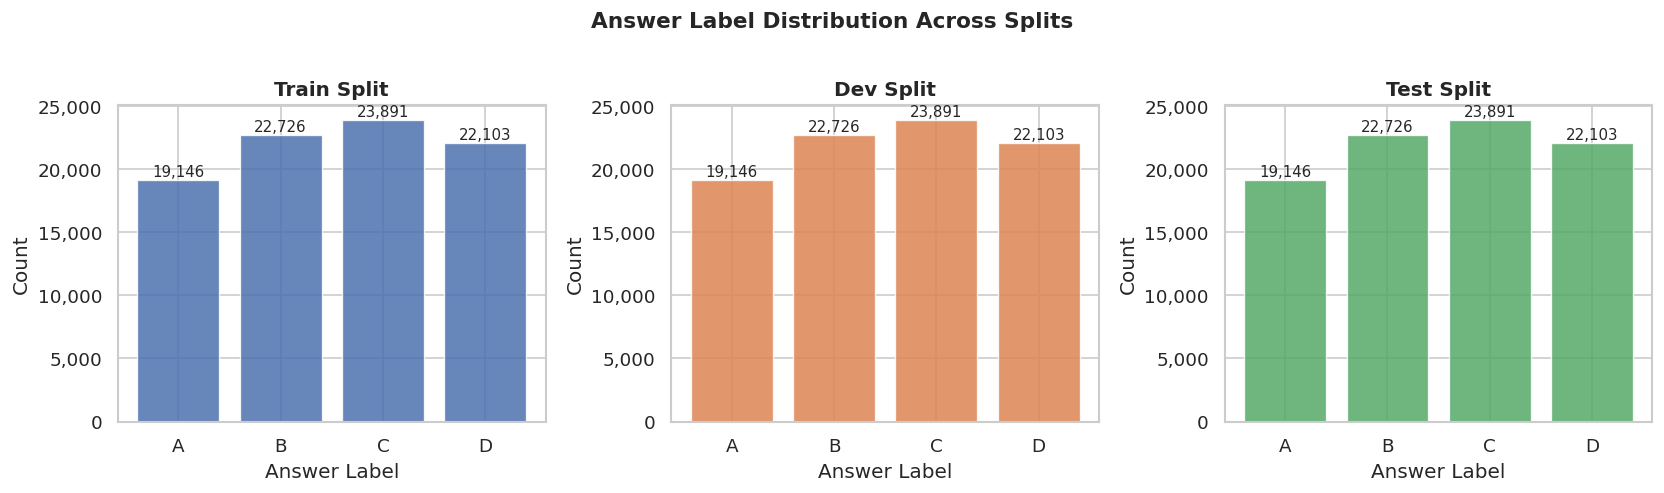


Train answer counts:
answer
A    19146
B    22726
C    23891
D    22103
Name: count, dtype: int64

Balance check - std of counts: 2021.1 (lower = more balanced)


In [51]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
splits = [('Train', train_df), ('Dev', dev_df), ('Test', test_df)]
colors = ['#4C72B0', '#DD8452', '#55A868']

for ax, (name, df), color in zip(axes, splits, colors):
    counts = df['answer'].value_counts().sort_index()
    bars = ax.bar(counts.index, counts.values, color=color, alpha=0.85, edgecolor='white', linewidth=0.8)
    ax.set_title(f'{name} Split', fontweight='bold')
    ax.set_xlabel('Answer Label')
    ax.set_ylabel('Count')
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    # Add value labels on top of bars
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Answer Label Distribution Across Splits', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'answer_distribution.png'), bbox_inches='tight')
plt.show()

print('\nTrain answer counts:')
print(train_df['answer'].value_counts().sort_index())
print(f'\nBalance check - std of counts: {train_df["answer"].value_counts().std():.1f} (lower = more balanced)')

## 5. Article (Passage) Length Distribution

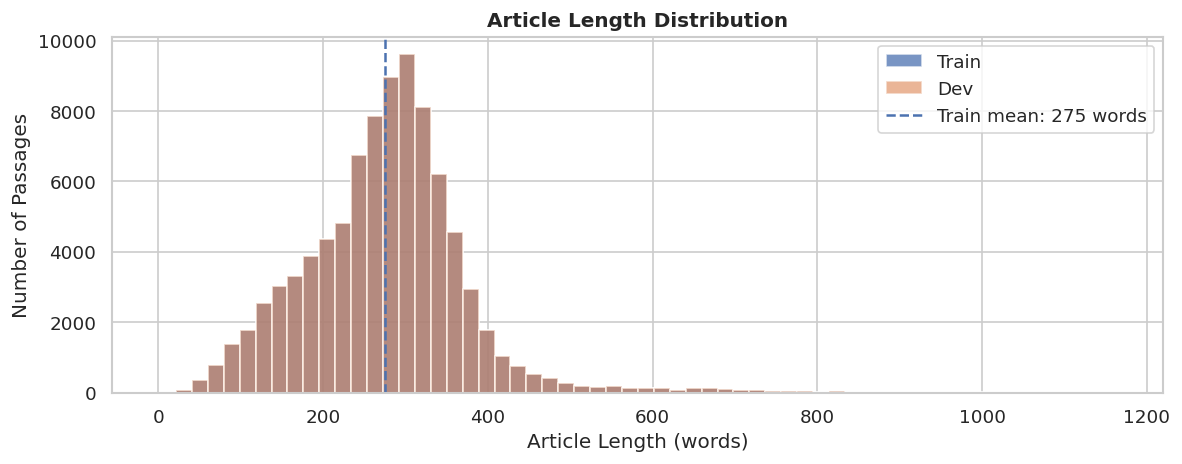

=== Article Length Statistics (Train) ===
count    87866.0
mean       275.0
std         97.9
min          2.0
25%        217.0
50%        279.0
75%        326.0
max       1162.0


In [52]:
# Word counts for articles
train_df['article_len'] = train_df['article'].str.split().str.len()
dev_df['article_len']   = dev_df['article'].str.split().str.len()
test_df['article_len']  = test_df['article'].str.split().str.len()

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(train_df['article_len'], bins=60, color='#4C72B0', alpha=0.75, label='Train', edgecolor='white')
ax.hist(dev_df['article_len'],   bins=60, color='#DD8452', alpha=0.60, label='Dev',   edgecolor='white')
ax.axvline(train_df['article_len'].mean(), color='#4C72B0', linestyle='--', linewidth=1.5,
           label=f'Train mean: {train_df["article_len"].mean():.0f} words')
ax.set_xlabel('Article Length (words)')
ax.set_ylabel('Number of Passages')
ax.set_title('Article Length Distribution', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'article_length.png'), bbox_inches='tight')
plt.show()

print('=== Article Length Statistics (Train) ===')
print(train_df['article_len'].describe().round(1).to_string())

## 6. Question Length Distribution

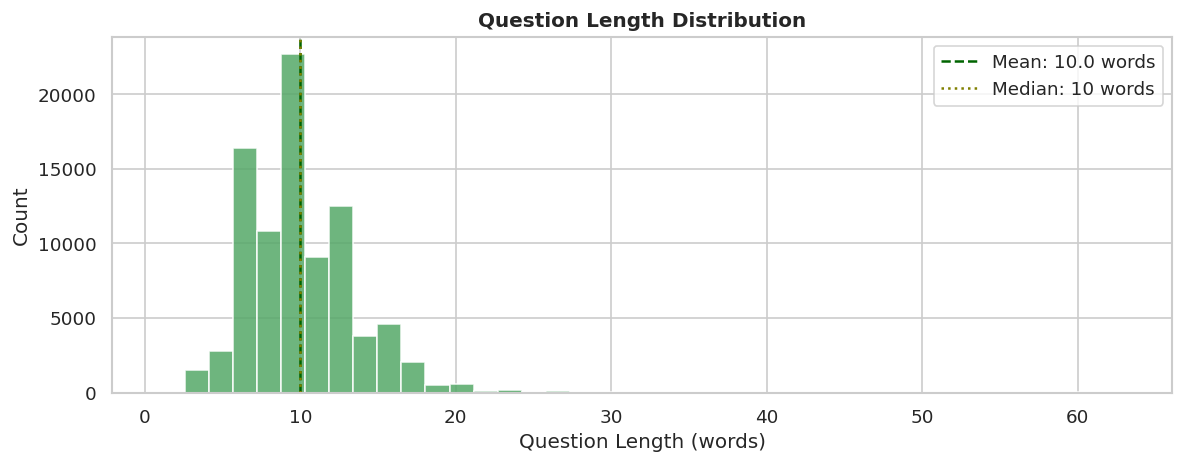

=== Question Length Statistics (Train) ===
count    87866.0
mean        10.0
std          3.4
min          1.0
25%          8.0
50%         10.0
75%         12.0
max         63.0


In [53]:
train_df['question_len'] = train_df['question'].str.split().str.len()

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(train_df['question_len'], bins=40, color='#55A868', alpha=0.85, edgecolor='white')
ax.axvline(train_df['question_len'].mean(), color='darkgreen', linestyle='--', linewidth=1.5,
           label=f'Mean: {train_df["question_len"].mean():.1f} words')
ax.axvline(train_df['question_len'].median(), color='olive', linestyle=':', linewidth=1.5,
           label=f'Median: {train_df["question_len"].median():.0f} words')
ax.set_xlabel('Question Length (words)')
ax.set_ylabel('Count')
ax.set_title('Question Length Distribution', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'question_length.png'), bbox_inches='tight')
plt.show()

print('=== Question Length Statistics (Train) ===')
print(train_df['question_len'].describe().round(1).to_string())

## 7. Answer Option Length Distribution
Longer answer options may be harder to classify. We compare lengths across A/B/C/D.

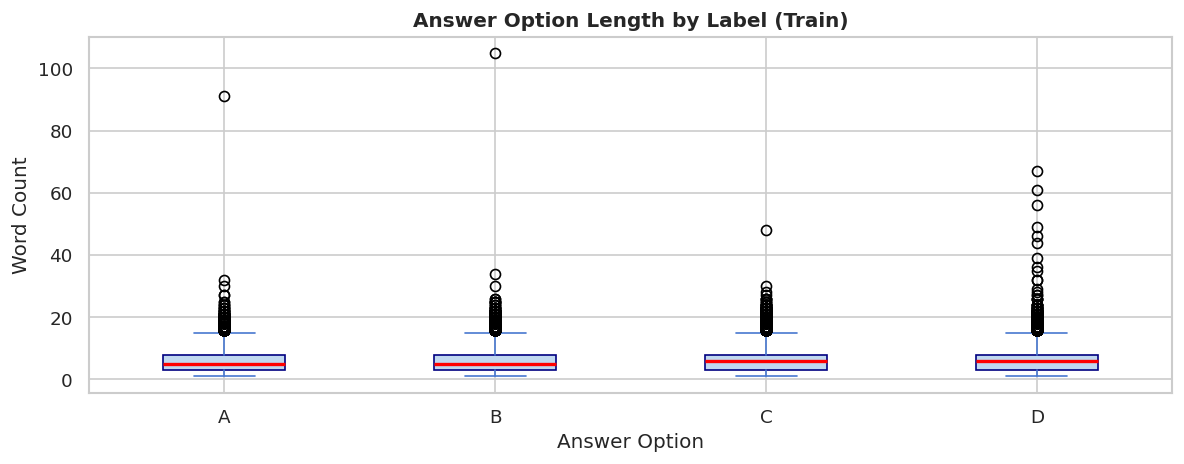

=== Mean Option Lengths ===
  Option A: 5.4 words (mean)
  Option B: 5.6 words (mean)
  Option C: 5.8 words (mean)
  Option D: 5.9 words (mean)


In [54]:
for opt in ['A', 'B', 'C', 'D']:
    train_df[f'{opt}_len'] = train_df[opt].str.split().str.len()

option_lengths = pd.DataFrame({
    opt: train_df[f'{opt}_len'] for opt in ['A', 'B', 'C', 'D']
})

fig, ax = plt.subplots(figsize=(10, 4))
option_lengths.plot(kind='box', ax=ax, patch_artist=True,
                    boxprops=dict(facecolor='#C0D8F0', color='navy'),
                    medianprops=dict(color='red', linewidth=2))
ax.set_xlabel('Answer Option')
ax.set_ylabel('Word Count')
ax.set_title('Answer Option Length by Label (Train)', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'option_lengths.png'), bbox_inches='tight')
plt.show()

print('=== Mean Option Lengths ===')
for opt in ['A','B','C','D']:
    print(f'  Option {opt}: {train_df[f"{opt}_len"].mean():.1f} words (mean)')

## 8. Question Type Breakdown (Wh-word Analysis)
This tells us which question templates (Who/What/Where/When/Why/How) are most common - directly useful for Model A's template generator.

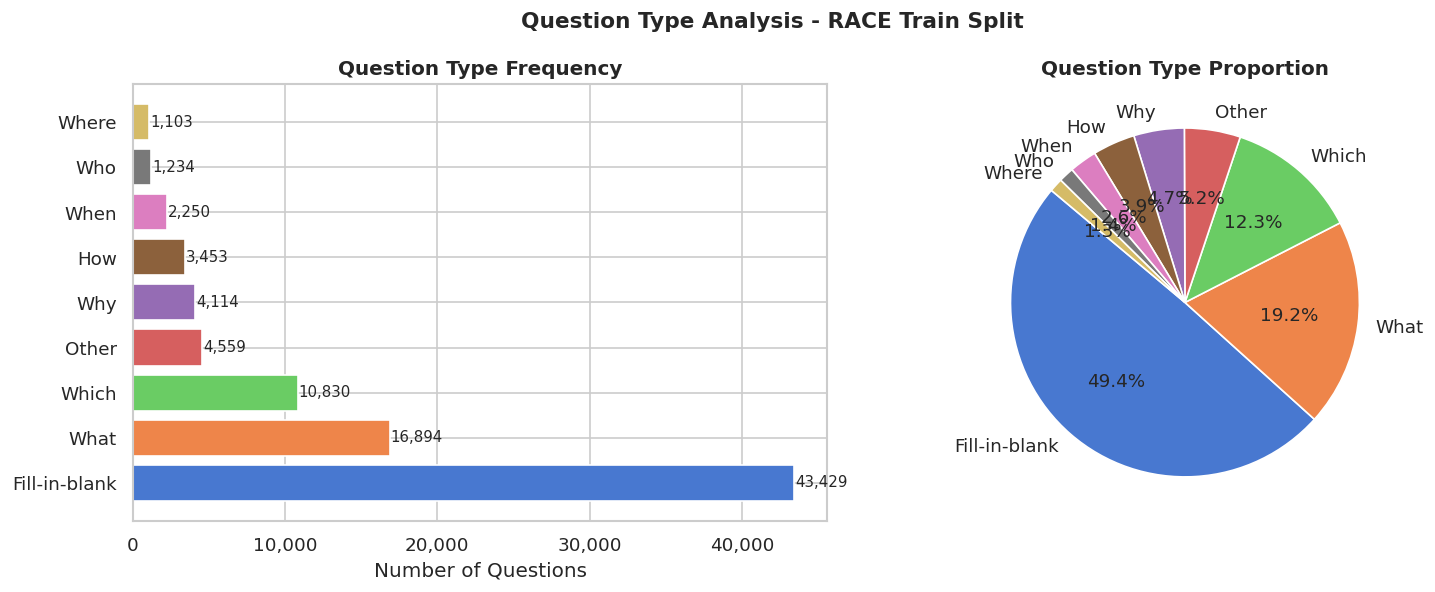

=== Question Type Counts ===
q_type
Fill-in-blank    43429
What             16894
Which            10830
Other             4559
Why               4114
How               3453
When              2250
Who               1234
Where             1103


In [55]:
def get_question_type(q):
    if not isinstance(q, str):
        return 'Other'
    q_lower = q.lower().strip()
    for wh in ['what', 'who', 'where', 'when', 'why', 'how', 'which']:
        if q_lower.startswith(wh):
            return wh.capitalize()
    # Check for fill-in-the-blank (underscore pattern)
    if '_' in q or '___' in q:
        return 'Fill-in-blank'
    return 'Other'

train_df['q_type'] = train_df['question'].apply(get_question_type)

q_type_counts = train_df['q_type'].value_counts()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart
bars = ax1.barh(q_type_counts.index, q_type_counts.values,
                color=sns.color_palette('muted', len(q_type_counts)),
                edgecolor='white')
ax1.set_xlabel('Number of Questions')
ax1.set_title('Question Type Frequency', fontweight='bold')
ax1.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for bar in bars:
    ax1.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
             f'{int(bar.get_width()):,}', va='center', fontsize=9)

# Pie chart
ax2.pie(q_type_counts.values, labels=q_type_counts.index,
        autopct='%1.1f%%', startangle=140,
        colors=sns.color_palette('muted', len(q_type_counts)))
ax2.set_title('Question Type Proportion', fontweight='bold')

plt.suptitle('Question Type Analysis - RACE Train Split', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'question_types.png'), bbox_inches='tight')
plt.show()

print('=== Question Type Counts ===')
print(q_type_counts.to_string())

## 9. Correct Answer vs Option Position
Do correct answers tend to appear in position A more than D? This matters for model bias.

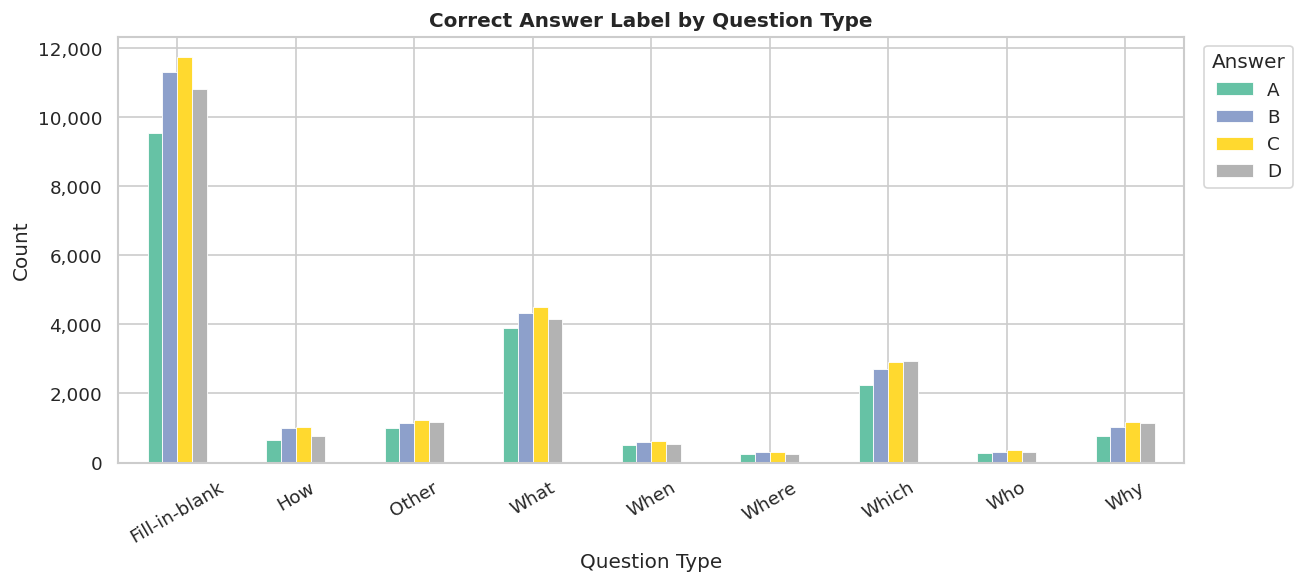

In [56]:
# Answer distribution per question type
answer_by_type = pd.crosstab(train_df['q_type'], train_df['answer'])

fig, ax = plt.subplots(figsize=(11, 5))
answer_by_type.plot(kind='bar', ax=ax, colormap='Set2',
                    edgecolor='white', linewidth=0.5)
ax.set_xlabel('Question Type')
ax.set_ylabel('Count')
ax.set_title('Correct Answer Label by Question Type', fontweight='bold')
ax.legend(title='Answer', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.tick_params(axis='x', rotation=30)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'answer_by_qtype.png'), bbox_inches='tight')
plt.show()

## 10. Vocabulary Size & Top Words

Article vocabulary (5k sample)  : 47,160 unique words
Question vocabulary (5k sample) : 5,178 unique words


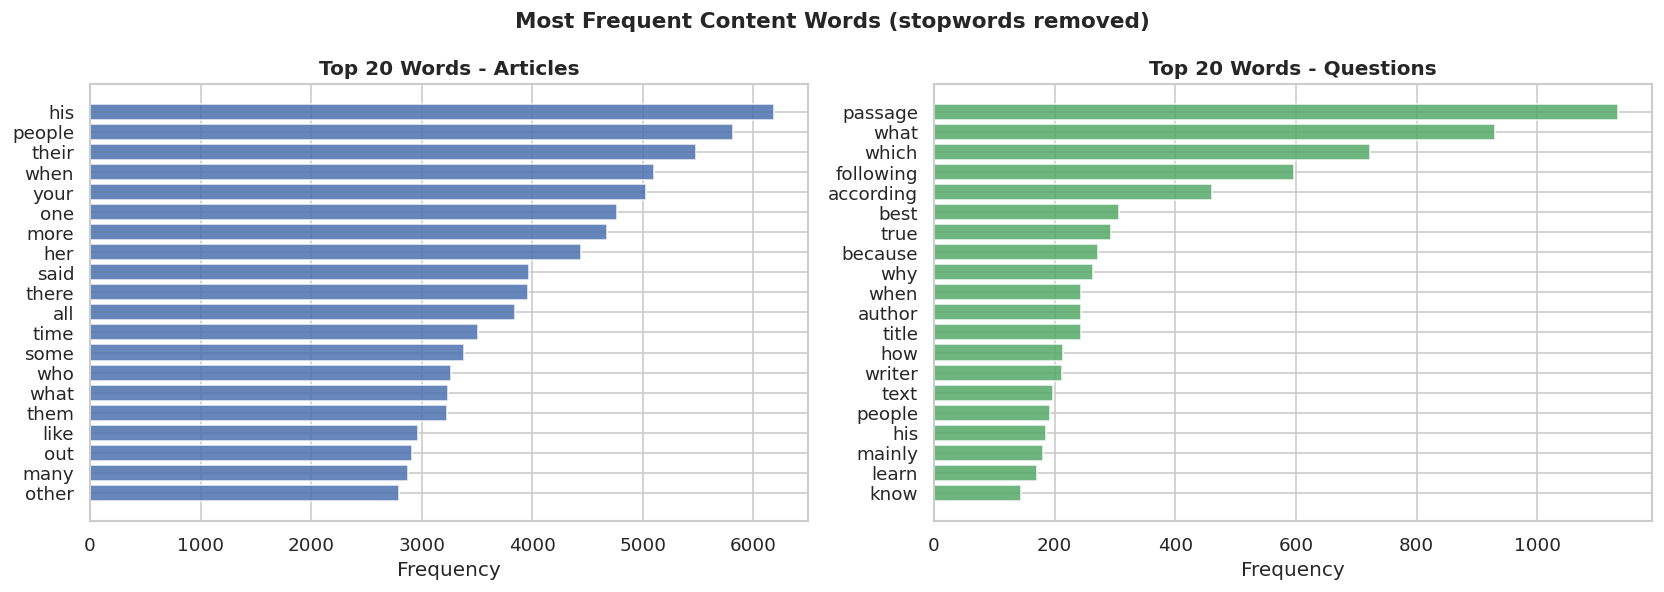

In [57]:
import string
from collections import Counter

STOPWORDS = set([
    'the','a','an','is','was','are','were','be','been','being',
    'have','has','had','do','does','did','will','would','could',
    'should','may','might','shall','can','to','of','in','for',
    'on','with','at','by','from','up','about','into','through',
    'it','its','he','she','they','we','i','you','this','that',
    'and','or','but','not','no','so','if','as','than','then'
])

def tokenize(text):
    if not isinstance(text, str):
        return []
    text = text.lower().translate(str.maketrans('', '', string.punctuation))
    return [w for w in text.split() if w not in STOPWORDS and len(w) > 2]

# Sample 5000 rows for speed
sample = train_df.sample(5000, random_state=42)
article_words = [w for text in sample['article'] for w in tokenize(text)]
question_words = [w for text in sample['question'] for w in tokenize(text)]

article_vocab  = len(set(article_words))
question_vocab = len(set(question_words))

top_article  = Counter(article_words).most_common(20)
top_question = Counter(question_words).most_common(20)

print(f'Article vocabulary (5k sample)  : {article_vocab:,} unique words')
print(f'Question vocabulary (5k sample) : {question_vocab:,} unique words')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

words_a, counts_a = zip(*top_article)
ax1.barh(words_a[::-1], counts_a[::-1], color='#4C72B0', alpha=0.85, edgecolor='white')
ax1.set_title('Top 20 Words - Articles', fontweight='bold')
ax1.set_xlabel('Frequency')

words_q, counts_q = zip(*top_question)
ax2.barh(words_q[::-1], counts_q[::-1], color='#55A868', alpha=0.85, edgecolor='white')
ax2.set_title('Top 20 Words - Questions', fontweight='bold')
ax2.set_xlabel('Frequency')

plt.suptitle('Most Frequent Content Words (stopwords removed)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'top_words.png'), bbox_inches='tight')
plt.show()

## 11. Article vs Question Length Correlation

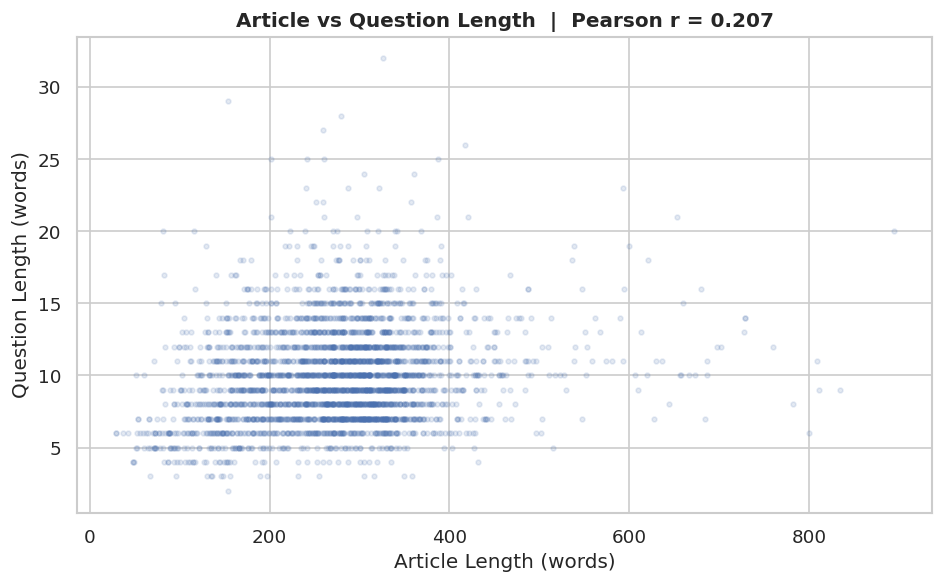

Pearson correlation: 0.2074
Weak correlation.


In [58]:
sample_corr = train_df.sample(3000, random_state=42)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(sample_corr['article_len'], sample_corr['question_len'],
           alpha=0.15, s=8, color='#4C72B0')
corr = sample_corr['article_len'].corr(sample_corr['question_len'])
ax.set_xlabel('Article Length (words)')
ax.set_ylabel('Question Length (words)')
ax.set_title(f'Article vs Question Length  |  Pearson r = {corr:.3f}', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'length_correlation.png'), bbox_inches='tight')
plt.show()

print(f'Pearson correlation: {corr:.4f}')
if abs(corr) < 0.1:
    print('Very weak correlation - article length does not predict question length.')
elif abs(corr) < 0.3:
    print('Weak correlation.')
else:
    print('Moderate/strong correlation.')

## 12. Summary Statistics Table
A clean summary table to include in the final report.

In [59]:
def split_stats(df, name):
    return {
        'Split'               : name,
        'Total Rows'          : f"{len(df):,}",
        'Avg Article Length'  : f"{df['article'].str.split().str.len().mean():.0f} words",
        'Max Article Length'  : f"{df['article'].str.split().str.len().max():,} words",
        'Avg Question Length' : f"{df['question'].str.split().str.len().mean():.1f} words",
        'Most Common Answer'  : df['answer'].value_counts().idxmax(),
        'Missing Values'      : df.isnull().sum().sum()
    }

summary_table = pd.DataFrame([
    split_stats(train_df, 'Train'),
    split_stats(dev_df,   'Dev'),
    split_stats(test_df,  'Test'),
])

print('=== Final Summary Statistics Table ===')
print(summary_table.to_string(index=False))

=== Final Summary Statistics Table ===
Split Total Rows Avg Article Length Max Article Length Avg Question Length Most Common Answer  Missing Values
Train     87,866          275 words        1,162 words          10.0 words                  C              28
  Dev     87,866          275 words        1,162 words          10.0 words                  C              14
 Test     87,866          275 words        1,162 words          10.0 words                  C              14


## 13. Save Plots Directory

In [60]:
os.makedirs(PLOTS_DIR, exist_ok=True)
print(f'All plots saved to {PLOTS_DIR}')
print('EDA complete!')

All plots saved to /content/drive/MyDrive/Colab Notebooks/AI PROJECT/plots/
EDA complete!


## Key Findings

Fill this in after running the notebook:

| Finding | Value |
|---------|-------|
| Total training samples | 87,866 |
| Average article length | 275.0 |
| Most common question type | Fill-in-blank |
| Answer label balance | 2021.1 |
| Missing values | 14 |
